<a href="https://colab.research.google.com/github/KarineMuradyan/University_OptimizationMethods/blob/main/lab3_GoldenSectionMethod/Personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Accurate Solution (using SciPy) ---
Exact Minimum Point (x*): 1.1572
Exact Minimum Value f(x*): -0.6609

Iter  a          b          x1         x2         f(x1)      f(x2)     
--------------------------------------------------------------------------------
0     0.0000     3.0000     1.1457     1.8540     -0.6608    -0.1141   
1     0.0000     1.8540     0.7083     1.1457     -0.4224    -0.6608   
2     0.7083     1.8540     1.1457     1.4166     -0.6608    -0.5839   
3     0.7083     1.4166     0.9792     1.1457     -0.6240    -0.6608   
--------------------------------------------------------------------------------
Final Minimum Point: x* ≈ 1.1979
Function Value at Minimum: f(x*) ≈ -0.6590


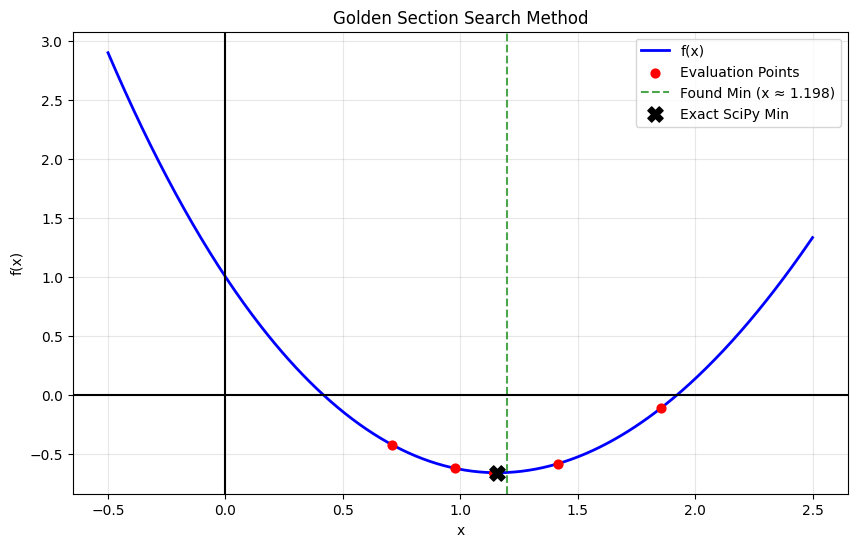

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Objective function
def f(x):
    return np.e**(-x)+x**2-2*x

# 2. Accurate Solution (using SciPy)
res = minimize(f, x0=1.5)
exact_x = res.x[0]
exact_f = res.fun

print("--- Accurate Solution (using SciPy) ---")
print(f"Exact Minimum Point (x*): {exact_x:.4f}")
print(f"Exact Minimum Value f(x*): {exact_f:.4f}\n")

# Parameters
a = 0
b = 3
epsilon = 0.5
all_x = []
all_y = []

# Step 0: Initial calculation
x1 = a + 0.3819 * (b - a)
x2 = a + 0.6180 * (b - a)
f1, f2 = f(x1), f(x2)

# Table Header
print(f"{'Iter':<5} {'a':<10} {'b':<10} {'x1':<10} {'x2':<10} {'f(x1)':<10} {'f(x2)':<10}")
print("-" * 80)

# 3. Golden Section Search Loop
k = 0
while (b - a) > epsilon:
    print(f"{k:<5} {a:<10.4f} {b:<10.4f} {x1:<10.4f} {x2:<10.4f} {f1:<10.4f} {f2:<10.4f}")

    # Store points for visualization
    all_x.extend([x1, x2])
    all_y.extend([f1, f2])

    if f1 <= f2:
        # Case (a): New interval is [a, x2]
        b = x2
        x2 = x1
        f2 = f1
        x1 = a + b - x2
        f1 = f(x1)
    else:
        # Case (b): New interval is [x1, b]
        a = x1
        x1 = x2
        f1 = f2
        x2 = a + b - x1
        f2 = f(x2)
    k += 1

# Final Result
x_star = (a + b) / 2
print("-" * 80)
print(f"Final Minimum Point: x* ≈ {x_star:.4f}")
print(f"Function Value at Minimum: f(x*) ≈ {f(x_star):.4f}")

# 4. Visualization (modified)
x_vals = np.linspace(-0.5, 2.5, 500)
plt.figure(figsize=(10, 6))
plt.plot(x_vals, f(x_vals), label='f(x)', color='blue', linewidth=2)

# Plotting the points where the function was evaluated
plt.scatter(all_x, all_y, color='red', s=40, zorder=5, label='Evaluation Points')

# Mark the final found minimum
plt.axvline(x_star, color='green', linestyle='--', alpha=0.7, label=f'Found Min (x ≈ {x_star:.3f})')

# Mark the exact SciPy minimum
plt.scatter(exact_x, exact_f, color='black', marker='X', s=120, zorder=6, label='Exact SciPy Min')

# Draw clear coordinate axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)

plt.title('Golden Section Search Method')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()